In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

## 1. Importing the Dataset

In [9]:
data = pd.read_csv('house_purchase.csv')

print(data.shape)
data.head()

(400, 3)


,Age,Income,Buy_House
0,56,135,Yes
1,35,85,Yes
2,59,41,Yes
3,37,51,Yes
4,30,67,Yes


## 2. Checking for Null Values

In [10]:
data.isnull().sum()

Age          0
Income       0
Buy_House    0
dtype: int64

## 3. Encoding the Target Variable

In [13]:
le = LabelEncoder()

data['Buy_House'] = le.fit_transform(data['Buy_House'])

print(data.head())

   Age  Income  Buy_House
0   56     135          1
1   35      85          1
2   59      41          1
3   37      51          1
4   30      67          1


## 4. Assigning Independent and Dependent Variables

In [14]:
x = data[['Age', 'Income']]
y = data['Buy_House']

print("Independent Variables:")
print(x.head())

print("\nDependent Variable:")
print(y.head())

Independent Variables:
   Age  Income
0   56     135
1   35      85
2   59      41
3   37      51
4   30      67

Dependent Variable:
0    1
1    1
2    1
3    1
4    1
Name: Buy_House, dtype: int64


## 5. Splitting the Dataset into Training and Testing Dataset

In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=5
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(320, 2)

(320,)

(80, 2)

(80,)

## 6. Fitting the Decision Tree Classifier

In [16]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=2,
    random_state=5
)

model.fit(x, y)

print(model)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=5)


## 7. Displaying Decision Tree Rules

In [17]:
print(tree.export_text(
    model,
    feature_names=['Age', 'Income']
))

|--- Age <= 29.50
|   |--- class: 0
|--- Age >  29.50
|   |--- Income <= 39.50
|   |   |--- class: 0
|   |--- Income >  39.50
|   |   |--- class: 1



## 8. Predicting the Test Data

In [23]:
y_pred = model.predict(x_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 0 0 1 0 1 1 0 1 0 1 1 1 1 1 1 0 1 1
 1 1 0 0 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0 1
 1 1 0 1 1 1]


## 9. Confusion Matrix

In [24]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[25  0]
 [ 0 55]]


## 10. Accuracy Score

In [25]:
accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", int(accuracy_score * 100), "%")

Accuracy Score: 1.0
Accuracy in Percentage: 100 %


## 11. Confusion Matrix Heatmap

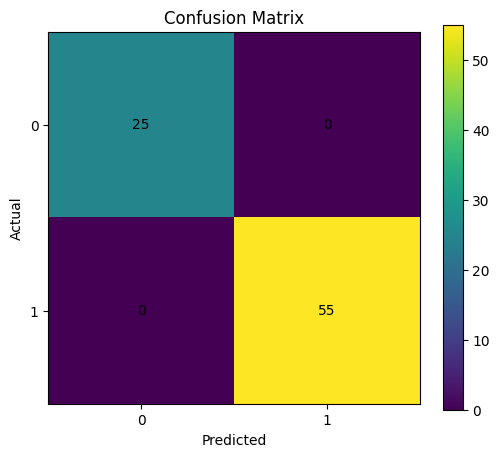

In [26]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

plt.figure(figsize=(6, 5))

plt.imshow(conf_mat)

plt.xticks(
    range(len(conf_mat.columns)),
    conf_mat.columns
)

plt.yticks(
    range(len(conf_mat.index)),
    conf_mat.index
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(conf_mat.index)):
    for j in range(len(conf_mat.columns)):
        plt.text(j, i, conf_mat.iloc[i, j],
                 ha='center', va='center')

plt.colorbar()
plt.show()

## 12. Decision Tree Visualization

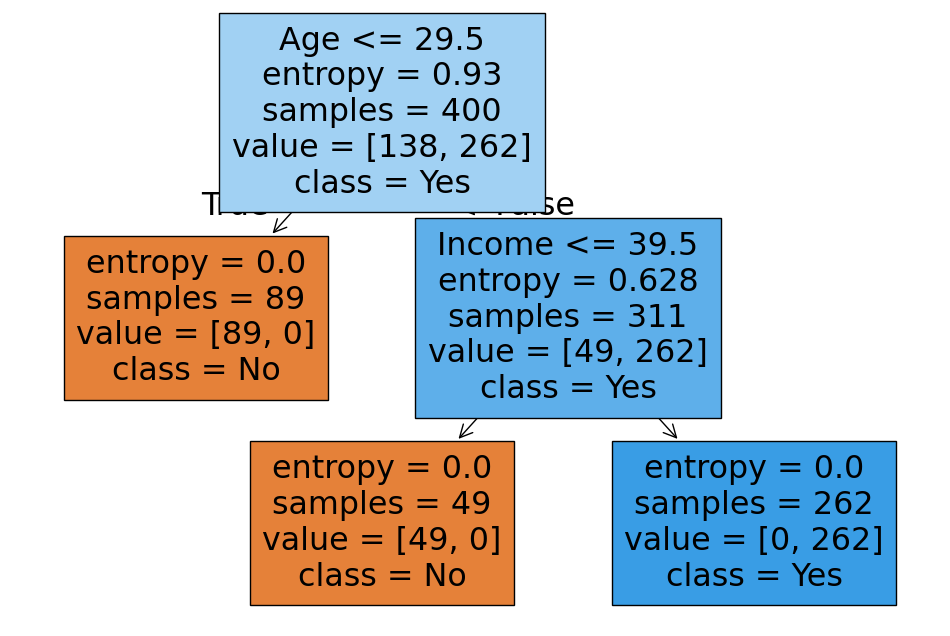

In [27]:
plt.figure(figsize=(12, 8))

tree.plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()

## 13. Predicting a New Person

In [28]:
new_person = pd.DataFrame(
    [[32, 45]],
    columns=['Age', 'Income']
)

prediction = model.predict(new_person)

print(
    "Prediction:",
    "Yes" if prediction[0] == 1 else "No"
)

Prediction: Yes
